✨ دقت مدل (R2 Score): 0.9815
🎯 میانگین خطای پیش‌بینی (MAE): 1.50 گرم


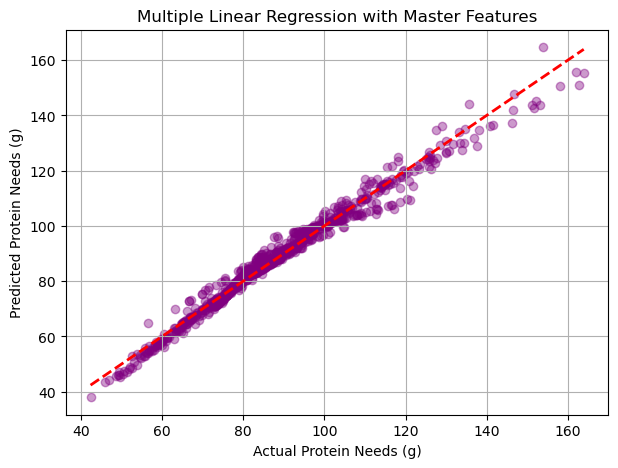

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ۱. بارگذاری دیتاست مستر
df_master = pd.read_csv('../data/processed/NHANES_Master_Dataset.csv')

# ۲. آماده‌سازی متغیرها (تبدیل جنسیت به عددی)
df_master['Is_Male'] = df_master['Gender'].map({'Male': 1, 'Female': 0})

# ۳. تفکیک ویژگی‌ها و هدف
features = ['Age', 'Is_Male', 'Weight_kg', 'Height_cm', 'BMI', 'Body_Fat_Percent', 'Lean_Mass_kg', 'Activity_Score', 'Daily_Protein_Intake_g', 'Genetic_Score']
X = df_master[features]
y = df_master['Protein_Requirement_g']

# ۴. تقسیم داده‌ها به قطعات آموزش و تست (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ۵. ساخت و آموزش مدل
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# ۶. پیش‌بینی و ارزیابی
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = np.mean(abs(y_test - y_pred))

print(f"✨ دقت مدل (R2 Score): {r2:.4f}")
print(f"🎯 میانگین خطای پیش‌بینی (MAE): {mae:.2f} گرم")

# ۷. رسم نمودار مقایسه
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Protein Needs (g)')
plt.ylabel('Predicted Protein Needs (g)')
plt.title('Multiple Linear Regression with Master Features')
plt.grid(True)
plt.show()

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# وارد کردن تنسورفلو برای شبکه عصبی
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=== 🚀 اجرای نسخه نهایی و یکپارچه مقایسه تمام مدل‌ها ===")

# ۱. بارگذاری داده‌ها
df_master = pd.read_csv('../data/processed/NHANES_Master_Dataset.csv')
if 'Gender' in df_master.columns:
    df_master['Is_Male'] = df_master['Gender'].map({'Male': 1, 'Female': 0})

# ستون‌ها دقیقاً بر اساس اکسل شما تنظیم شده است
features = [
    'Age', 'Is_Male', 'Weight_kg', 'Height_cm', 'BMI', 
    'Body_Fat_Percent', 'Lean_Mass_kg', 'Activity_Score', 
    'Daily_Protein_Intake_g', 'Genetic_Score'
]

X = df_master[features]
y = df_master['Protein_Requirement_g']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# استانداردسازی برای مدل‌های حساس (SVR, KNN, Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ذخیره نتایج همه مدل‌ها در یک لیست
final_results = []

# ---- بخش اول: مدل‌های درختی و کلاسیک ----
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Polynomial Regression (Deg 2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'Support Vector Regression (SVR)': make_pipeline(StandardScaler(), SVR(C=100, epsilon=0.1)),
    'K-Nearest Neighbors (KNN)': make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.1, verbose=0, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    final_results.append({
        'Model': name,
        'R² Score': round(r2_score(y_test, preds), 4),
        'MAE (g)': round(mean_absolute_error(y_test, preds), 4),
        'RMSE (g)': round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    })

# ---- بخش دوم: لایه عمیق شبکه عصبی قیفی ----
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

nn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)
nn_preds = nn_model.predict(X_test_scaled).flatten()

final_results.append({
    'Model': '🧠 Funnel Neural Network',
    'R² Score': round(r2_score(y_test, nn_preds), 4),
    'MAE (g)': round(mean_absolute_error(y_test, nn_preds), 4),
    'RMSE (g)': round(np.sqrt(mean_squared_error(y_test, nn_preds)), 4)
})

# ---- نمایش جدول نهایی ----
df_final = pd.DataFrame(final_results).sort_values(by='R² Score', ascending=False)
print("\n📊 جدول نهایی و بی‌پایان پورتفولیو شما:")
print(df_final.to_string(index=False))

=== 🚀 اجرای نسخه نهایی و یکپارچه مقایسه تمام مدل‌ها ===


C:\Users\hi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📊 جدول نهایی و بی‌پایان پورتفولیو شما:
                          Model  R² Score  MAE (g)  RMSE (g)
  Polynomial Regression (Deg 2)    1.0000   0.0026    0.0030
                        XGBoost    0.9977   0.3608    0.8221
                       CatBoost    0.9962   0.3720    1.0641
                  Random Forest    0.9949   0.4129    1.2246
Support Vector Regression (SVR)    0.9949   0.2492    1.2331
        🧠 Funnel Neural Network    0.9885   1.2686    1.8474
   Linear Regression (Baseline)    0.9815   1.5039    2.3405
               Ridge Regression    0.9815   1.5037    2.3405
      K-Nearest Neighbors (KNN)    0.9656   1.9020    3.1950
